In [71]:
options(repos = c(CRAN = "https://cloud.r-project.org"))

if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, stringr, readxl, data.table, gdata, scales, data.table)

In [72]:
data.2010 <- read.csv('../data/data-2010.csv')
data.2011 <- read.csv('../data/data-2011.csv')
data.2012 <- read.csv('../data/data-2012.csv')
data.2013 <- read.csv('../data/data-2013.csv')
data.2014 <- read.csv('../data/data-2014.csv')
data.2015 <- read.csv('../data/data-2015.csv')

In [73]:
fix_type <- function(df) {
  df$org_parent <- as.character(df$org_parent)
  df
}

data.2011 <- fix_type(data.2011)

In [74]:
data.full <- bind_rows(data.2010, data.2011, data.2012, data.2013, data.2014, data.2015)  %>%
  mutate(market_share = avg_enrollment / avg_enrolled)

# Problem 1

In [75]:
options(knitr.kable.NA = 0)
library(knitr)
library(kableExtra)

data.full %>%
  group_by(year) %>%
  summarise(
    avg_star      = round(mean(Star_Rating,   na.rm = TRUE), 2),
    avg_enroll    = round(mean(avg_enrollment, na.rm = TRUE), 2),
    avg_share     = round(mean(market_share,   na.rm = TRUE), 4),
    total_plans   = n()
  ) %>%
  kable(
    col.names = c("Year", "Avg Star Rating", "Avg Enrollments", 
                  "Avg Market Share", "Total Plans"),
    digits    = c(0, 2, 2, 4, 0),
    format.args = list(big.mark = ","),
    booktabs  = TRUE,
    caption   = "Summary Statistics by Year"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>Summary Statistics by Year</caption>
 <thead>
  <tr>
   <th style="text-align:right;"> Year </th>
   <th style="text-align:right;"> Avg Star Rating </th>
   <th style="text-align:right;"> Avg Enrollments </th>
   <th style="text-align:right;"> Avg Market Share </th>
   <th style="text-align:right;"> Total Plans </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2,010 </td>
   <td style="text-align:right;"> 2.97 </td>
   <td style="text-align:right;"> 256.35 </td>
   <td style="text-align:right;"> 0.0658 </td>
   <td style="text-align:right;"> 108,222 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2,011 </td>
   <td style="text-align:right;"> 3.26 </td>
   <td style="text-align:right;"> 343.36 </td>
   <td style="text-align:right;"> 0.0855 </td>
   <td style="text-align:right;"> 68,003 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-wei

## Problem 2

In [76]:
options(knitr.kable.NA = 0)
library(knitr)
library(kableExtra)

data.full %>%
  filter(is.na(Star_Rating)) %>%
  group_by(year) %>%
  summarise(
    avg_enroll  = round(mean(avg_enrollment, na.rm = TRUE), 2),
    avg_share   = round(mean(market_share,   na.rm = TRUE), 4),
    total_plans = n()
  ) %>%
  kable(
    col.names   = c("Year", "Avg Enrollments", "Avg Market Share", "Total Plans"),
    digits      = c(0, 2, 4, 0),
    format.args = list(big.mark = ","),
    booktabs    = TRUE,
    caption     = "Summary Statistics for Plans Without a Star Rating"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>Summary Statistics for Plans Without a Star Rating</caption>
 <thead>
  <tr>
   <th style="text-align:right;"> Year </th>
   <th style="text-align:right;"> Avg Enrollments </th>
   <th style="text-align:right;"> Avg Market Share </th>
   <th style="text-align:right;"> Total Plans </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2,010 </td>
   <td style="text-align:right;"> 107.34 </td>
   <td style="text-align:right;"> 0.0673 </td>
   <td style="text-align:right;"> 48,643 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2,011 </td>
   <td style="text-align:right;"> 167.90 </td>
   <td style="text-align:right;"> 0.0900 </td>
   <td style="text-align:right;"> 12,754 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2,012 </td>
   <td style="text-align:right;"> 172.73 </td>
   <td style="text-align:right;"> 0.0567 </td>
   <

## Problem 3

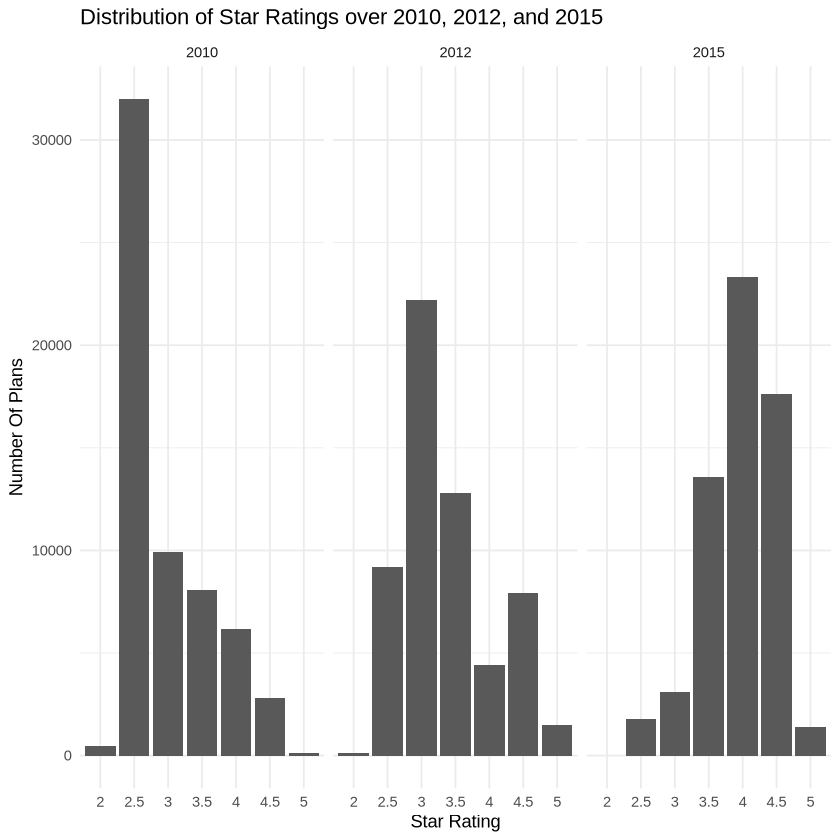

In [77]:
data.full %>%
  filter(year %in% c(2010, 2012, 2015), !is.na(Star_Rating)) %>%
  mutate(year = as.factor(year)) %>%
  ggplot(aes(x = as.factor(Star_Rating))) +
  geom_bar() +
  facet_wrap(~ year) +
  labs(
    title = "Distribution of Star Ratings over 2010, 2012, and 2015",
    x = "Star Rating",
    y = "Number Of Plans"
  ) +
  theme_minimal()

We note that there is a steep decrease in the number of high-rated plans in 2010, whereas in 2012, the difference is less stark, with improvement in 3-star-rated plans, and in 2015, we notice an improvement, with the existence of a larger number of high-rated plans.

## Problem 4

In [78]:
data.full <- data.full %>%
  mutate(
    star_3   = as.integer(Star_Rating == 3),
    star_35  = as.integer(Star_Rating == 3.5),
    star_4   = as.integer(Star_Rating == 4),
    star_45  = as.integer(Star_Rating >= 4.5)
  )

estimate <- list()

options(knitr.kable.NA = 0)
library(knitr)
library(kableExtra)

estimate <- list()

for(yr in 2010:2015){
  ols <- lm(market_share ~ star_3 + star_35 + star_4 + star_45,
            data = data.full %>% filter(year == yr, !is.na(Star_Rating), !is.na(market_share)))
  estimate[[as.character(yr)]] <- coef(ols)
}

ols_table <- as.data.frame(estimate)
colnames(ols_table) <- c("2010", "2011", "2012", "2013", "2014", "2015")

ols_table %>%
  kable(
    col.names   = c("2010", "2011", "2012", "2013", "2014", "2015"),
    digits      = 4,
    format.args = list(big.mark = ","),
    booktabs    = TRUE,
    caption     = "OLS Estimates of Star Rating Effect on Market Share by Year"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  pack_rows("Reference: <= 2.5 Stars", 1, 1) %>%
  pack_rows("Star Rating Indicators",  2, 5)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>OLS Estimates of Star Rating Effect on Market Share by Year</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;">   </th>
   <th style="text-align:right;font-weight: bold;"> 2010 </th>
   <th style="text-align:right;font-weight: bold;"> 2011 </th>
   <th style="text-align:right;font-weight: bold;"> 2012 </th>
   <th style="text-align:right;font-weight: bold;"> 2013 </th>
   <th style="text-align:right;font-weight: bold;"> 2014 </th>
   <th style="text-align:right;font-weight: bold;"> 2015 </th>
  </tr>
 </thead>
<tbody>
  <tr grouplength="1"><td colspan="7" style="border-bottom: 1px solid;"><strong>Reference: &lt;= 2.5 Stars</strong></td></tr>
<tr>
   <td style="text-align:left;font-weight: bold;padding-left: 2em;" indentlevel="1"> (Intercept) </td>
   <td style="text-align:right;"> 0.0634 </td>
   <td style="text-align:right;"> 0.0702 </td>
   <td style="text-align:right;"> 0.0789 </td

## Problem 5

Here we create raw rating as simple average or aggregate of all considerable factors.

In [79]:
quality_vars <- c(
  "breastcancer_screen",
  "rectalcancer_screen",
  "cv_diab_cholscreen",
  "glaucoma_test",
  "monitoring",
  "flu_vaccine",
  "pn_vaccine",
  "physical_health",
  "mental_health",
  "osteo_test",
  "physical_monitor",
  "primaryaccess",
  "osteo_manage",
  "diab_healthy",
  "bloodpressure",
  "ra_manage",
  "copd_test",
  "bladder",
  "falling",
  "nodelays",
  "doctor_communicate",
  "carequickly",
  "customer_service",
  "overallrating_care",
  "overallrating_plan",
  "complaints_plan",
  "appeals_timely",
  "appeals_review",
  "leave_plan",
  "audit_problems",
  "hold_times",
  "info_accuracy",
  "ttyt_available"
)

data.2010 <- data.2010 %>%
  rowwise() %>%
  mutate(
    raw_rating = mean(c_across(all_of(quality_vars)), na.rm = TRUE)
  ) %>%
  ungroup()

In [80]:
options(knitr.kable.NA = 0)
library(knitr)
library(kableExtra)

data.2010 %>%
  filter(!is.na(avg_enrollment), !is.na(raw_rating), !is.na(partc_score)) %>%
  mutate(
    round_ups = ifelse(raw_rating >= 2.75 & raw_rating < 3.00 & partc_score == 3.0, "Rounded Up to 3",
               ifelse(raw_rating >= 3.25 & raw_rating < 3.50 & partc_score == 3.5, "Rounded Up to 3.5",
               ifelse(raw_rating >= 3.75 & raw_rating < 4.00 & partc_score == 4.0, "Rounded Up to 4",
               ifelse(raw_rating >= 4.25 & raw_rating < 4.50 & partc_score == 4.5, "Rounded Up to 4.5",
               ifelse(raw_rating >= 4.75 & partc_score == 5.0,                     "Rounded Up to 5",
               NA)))))
  ) %>%
  filter(!is.na(round_ups)) %>%
  count(round_ups) %>%
  kable(
    col.names   = c("Star Rating", "Number of Plans"),
    digits      = 0,
    format.args = list(big.mark = ","),
    booktabs    = TRUE,
    caption     = "Number of Plans Rounded Up to Each Star Rating (2010)"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>Number of Plans Rounded Up to Each Star Rating (2010)</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Star Rating </th>
   <th style="text-align:right;font-weight: bold;"> Number of Plans </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Rounded Up to 3 </td>
   <td style="text-align:right;"> 1,672 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Rounded Up to 3.5 </td>
   <td style="text-align:right;"> 1,762 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Rounded Up to 4 </td>
   <td style="text-align:right;"> 1,594 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Rounded Up to 4.5 </td>
   <td style="text-align:right;"> 193 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Rounded Up to 5 </td>
   <td style="text-align:right;"> 29 </td>
  </tr>
</tb

## Problem 6

In [81]:
ma_25star_candidates <- data.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(2.5, 3)
  )

n_candidates_total <- nrow(ma_25star_candidates)
n_candidates_by_score <- ma_25star_candidates %>% count(partc_score)

ma_25star <- ma_25star_candidates %>%
  filter(
    raw_rating >= 2.5,
    raw_rating <= 3,
    (raw_rating >= 2.75 & Star_Rating == 3) | (raw_rating < 2.75 & Star_Rating == 2.5)
  )

ma.rd1 <- ma_25star %>%
  mutate(market_share = avg_enrollment / avg_enrolled,
         score = raw_rating - 2.75,
         treat = (score>=0),
         window = (score>=-.125 & score<=.125),
         score_treat=score*treat)

star25.1 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd1 %>% filter(window==TRUE)))
est1 <- as.numeric(star25.1$coef[3])

print(star25.1)


Call:
lm(formula = market_share ~ score + treat + score_treat, data = (ma.rd1 %>% 
    filter(window == TRUE)))

Coefficients:
(Intercept)        score    treatTRUE  score_treat  
    0.01629     -0.74028      0.05460      0.95798  



In [82]:
ma_25star_candidates <- data.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(3, 3.5)
  )

n_candidates_total <- nrow(ma_25star_candidates)
n_candidates_by_score <- ma_25star_candidates %>% count(partc_score)

ma_25star <- ma_25star_candidates %>%
  filter(
    raw_rating >= 3,
    raw_rating <= 3.5,
    (raw_rating >= 3.25 & Star_Rating == 3.5) | (raw_rating < 3.25 & Star_Rating == 3)
  )

ma.rd2 <- ma_25star %>%
  mutate(market_share = avg_enrollment / avg_enrolled,
         score = raw_rating - 3.25,
         treat = (score>=0),
         window = (score>=-.125 & score<=.125),
         score_treat=score*treat)

star25.2 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd2 %>% filter(window==TRUE)))
est2 <- as.numeric(star25.2$coef[3])

print(star25.2)


Call:
lm(formula = market_share ~ score + treat + score_treat, data = (ma.rd2 %>% 
    filter(window == TRUE)))

Coefficients:
(Intercept)        score    treatTRUE  score_treat  
    0.10229      0.41673     -0.03953     -0.46739  



In [83]:
options(knitr.kable.NA = 0)
library(knitr)
library(kableExtra)

data.frame(
  Statistic   = c("Intercept", "Rounded", "Running Score", "Interaction", "Num.Obs.", "R2"),
  `3 Stars`   = c(
    round(coef(star25.1)["(Intercept)"], 3),
    round(coef(star25.1)["treatTRUE"],   3),
    round(coef(star25.1)["score"],        3),
    round(coef(star25.1)["score_treat"],  3),
    nobs(star25.1),
    round(summary(star25.1)$r.squared,   3)
  ),
  `3.5 Stars` = c(
    round(coef(star25.2)["(Intercept)"], 3),
    round(coef(star25.2)["treatTRUE"],   3),
    round(coef(star25.2)["score"],        3),
    round(coef(star25.2)["score_treat"],  3),
    nobs(star25.2),
    round(summary(star25.2)$r.squared,   3)
  ),
  check.names = FALSE
) %>%
  kable(
    col.names   = c("Statistic", "3 Stars", "3.5 Stars"),
    digits      = 3,
    booktabs    = TRUE,
    caption     = "RD Estimates at 3-Star and 3.5-Star Thresholds"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  pack_rows("Coefficients", 1, 4) %>%
  pack_rows("Model Fit",    5, 6)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>RD Estimates at 3-Star and 3.5-Star Thresholds</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Statistic </th>
   <th style="text-align:right;font-weight: bold;"> 3 Stars </th>
   <th style="text-align:right;font-weight: bold;"> 3.5 Stars </th>
  </tr>
 </thead>
<tbody>
  <tr grouplength="4"><td colspan="3" style="border-bottom: 1px solid;"><strong>Coefficients</strong></td></tr>
<tr>
   <td style="text-align:left;font-weight: bold;padding-left: 2em;" indentlevel="1"> Intercept </td>
   <td style="text-align:right;"> 0.016 </td>
   <td style="text-align:right;"> 0.102 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;padding-left: 2em;" indentlevel="1"> Rounded </td>
   <td style="text-align:right;"> 0.055 </td>
   <td style="text-align:right;"> -0.040 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;padding-left: 2em;" indentlevel="1"> Runni

## Problem 7

In [84]:
ma_25star_candidates <- data.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(2.5, 3)
  )

n_candidates_total <- nrow(ma_25star_candidates)
n_candidates_by_score <- ma_25star_candidates %>% count(partc_score)

ma_25star <- ma_25star_candidates %>%
  filter(
    raw_rating >= 2.5,
    raw_rating <= 3,
    (raw_rating >= 2.75 & Star_Rating == 3) | (raw_rating < 2.75 & Star_Rating == 2.5)
  )

ma.rd1 <- ma_25star %>%
  mutate(market_share = avg_enrollment / avg_enrolled,
         score = raw_rating - 2.75,
         treat = (score>=0),
         window1 = (score>=-.1 & score<=.1),
         window2 = (score>=-.11 & score<=.11),
         window3 = (score>=-.12 & score<=.12),
         window4 = (score>=-.13 & score<=.13),
         window5 = (score>=-.14 & score<=.14),
         window6 = (score>=-.15 & score<=.15),
         score_treat=score*treat)

star25.1 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd1 %>% filter(window1==TRUE)))
star25.2 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd1 %>% filter(window2==TRUE)))
star25.3 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd1 %>% filter(window3==TRUE)))
star25.4 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd1 %>% filter(window4==TRUE)))
star25.5 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd1 %>% filter(window5==TRUE)))
star25.6 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd1 %>% filter(window6==TRUE)))
est1 <- as.numeric(star25.1$coef[3])
est2 <- as.numeric(star25.2$coef[3])
est3 <- as.numeric(star25.3$coef[3])
est4 <- as.numeric(star25.4$coef[3])
est5 <- as.numeric(star25.5$coef[3])
est6 <- as.numeric(star25.6$coef[3])

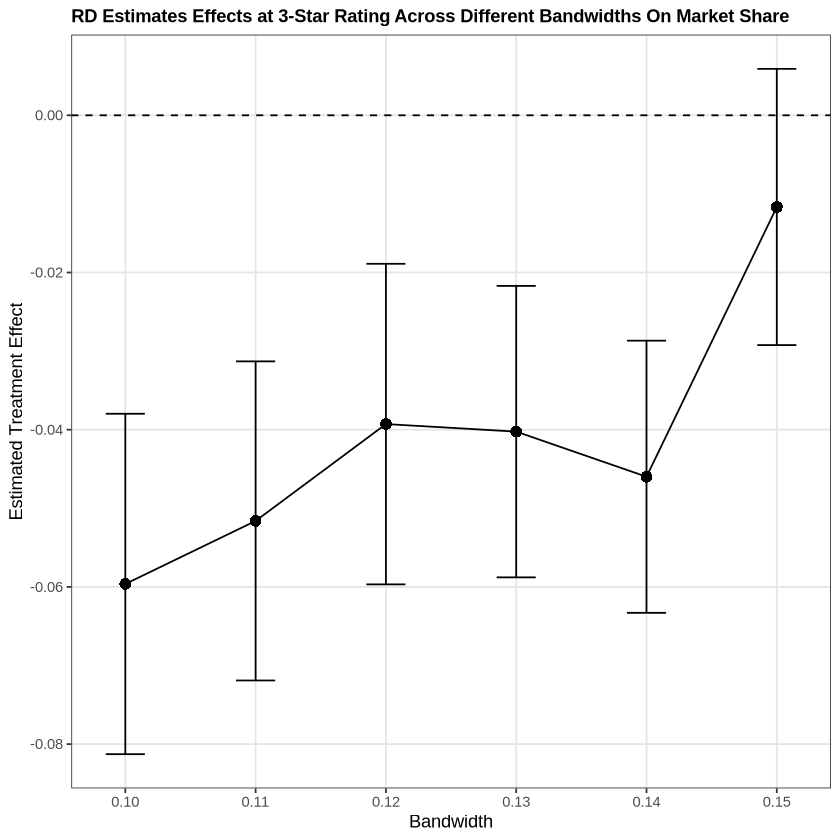

In [96]:
# Create a dataframe of estimates and bandwidths
rd_results <- data.frame(
  bandwidth = c(0.10, 0.11, 0.12, 0.13, 0.14, 0.15),
  estimate  = c(est1, est2, est3, est4, est5, est6)
)

# Add confidence intervals
se_list <- c(
  summary(star25.1)$coef[3, 2],
  summary(star25.2)$coef[3, 2],
  summary(star25.3)$coef[3, 2],
  summary(star25.4)$coef[3, 2],
  summary(star25.5)$coef[3, 2],
  summary(star25.6)$coef[3, 2]
)

rd_results <- rd_results %>%
  mutate(
    se    = se_list,
    ci_lo = estimate - 1.96 * se,
    ci_hi = estimate + 1.96 * se
  )

# Plot
ggplot(rd_results, aes(x = bandwidth, y = estimate)) +
  geom_point(size = 3, shape = 16, color = "black") +
  geom_line(color = "black", linetype = "solid") +
  geom_errorbar(aes(ymin = ci_lo, ymax = ci_hi), width = 0.003, color = "black") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
  scale_x_continuous(breaks = rd_results$bandwidth) +
  labs(
    title = "RD Estimates Effects at 3.5-Star Rating Across Different Bandwidths On Market Share",
    x     = "Bandwidth",
    y     = "Estimated Treatment Effect"
  ) +
  theme_bw() +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(color = "grey90"),
    plot.title       = element_text(size = 11, face = "bold")
  )

In [86]:
ma_25star_candidates <- data.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(3, 3.5)
  )

n_candidates_total <- nrow(ma_25star_candidates)
n_candidates_by_score <- ma_25star_candidates %>% count(partc_score)

ma_25star <- ma_25star_candidates %>%
  filter(
    raw_rating >= 3,
    raw_rating <= 3.5,
    (raw_rating >= 3.25 & Star_Rating == 3.5) | (raw_rating < 3.25 & Star_Rating == 3)
  )

ma.rd2 <- ma_25star %>%
  mutate(market_share = avg_enrollment / avg_enrolled,
         score = raw_rating - 3.25,
         treat = (score>=0),
         window1 = (score>=-.1 & score<=.1),
         window2 = (score>=-.11 & score<=.11),
         window3 = (score>=-.12 & score<=.12),
         window4 = (score>=-.13 & score<=.13),
         window5 = (score>=-.14 & score<=.14),
         window6 = (score>=-.15 & score<=.15),
         score_treat=score*treat)

star25.1 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd2 %>% filter(window1==TRUE)))
star25.2 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd2 %>% filter(window2==TRUE)))
star25.3 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd2 %>% filter(window3==TRUE)))
star25.4 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd2 %>% filter(window4==TRUE)))
star25.5 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd2 %>% filter(window5==TRUE)))
star25.6 <- lm(market_share ~ score + treat + score_treat, data= (ma.rd2 %>% filter(window6==TRUE)))
est1 <- as.numeric(star25.1$coef[3])
est2 <- as.numeric(star25.2$coef[3])
est3 <- as.numeric(star25.3$coef[3])
est4 <- as.numeric(star25.4$coef[3])
est5 <- as.numeric(star25.5$coef[3])
est6 <- as.numeric(star25.6$coef[3])

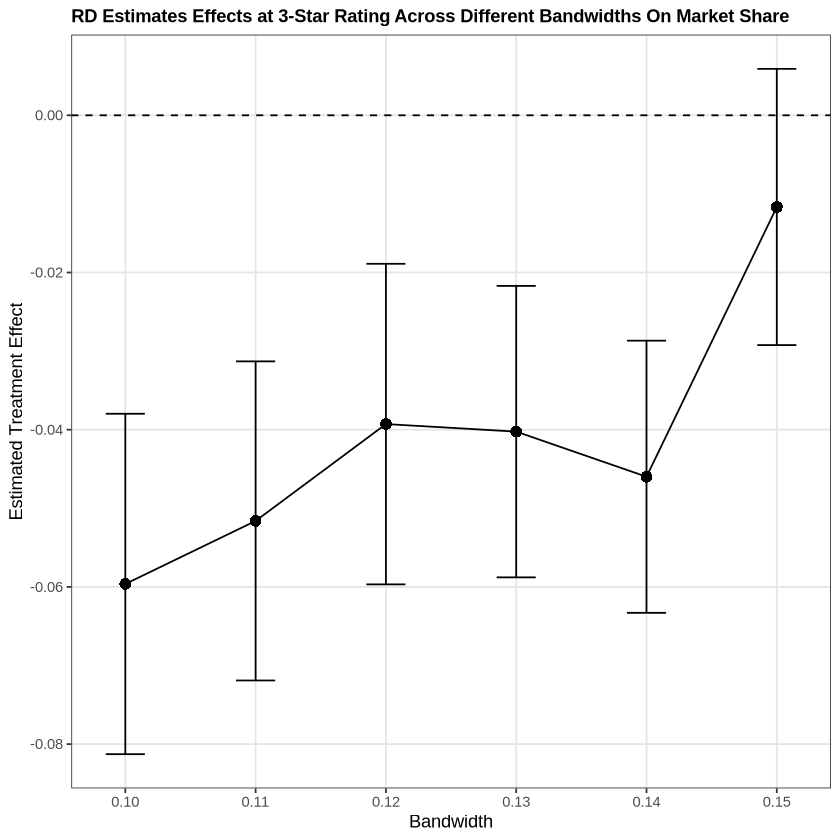

In [95]:
# Create a dataframe of estimates and bandwidths
rd_results <- data.frame(
  bandwidth = c(0.10, 0.11, 0.12, 0.13, 0.14, 0.15),
  estimate  = c(est1, est2, est3, est4, est5, est6)
)

# Add confidence intervals
se_list <- c(
  summary(star25.1)$coef[3, 2],
  summary(star25.2)$coef[3, 2],
  summary(star25.3)$coef[3, 2],
  summary(star25.4)$coef[3, 2],
  summary(star25.5)$coef[3, 2],
  summary(star25.6)$coef[3, 2]
)

rd_results <- rd_results %>%
  mutate(
    se    = se_list,
    ci_lo = estimate - 1.96 * se,
    ci_hi = estimate + 1.96 * se
  )

# Plot
ggplot(rd_results, aes(x = bandwidth, y = estimate)) +
  geom_point(size = 3, shape = 16, color = "black") +
  geom_line(color = "black", linetype = "solid") +
  geom_errorbar(aes(ymin = ci_lo, ymax = ci_hi), width = 0.003, color = "black") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
  scale_x_continuous(breaks = rd_results$bandwidth) +
  labs(
    title = "RD Estimates Effects at 3.5-Star Rating Across Different Bandwidths On Market Share",
    x     = "Bandwidth",
    y     = "Estimated Treatment Effect"
  ) +
  theme_bw() +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(color = "grey90"),
    plot.title       = element_text(size = 11, face = "bold")
  )

We note that findings are indeed sensitive to bandwidth choice. For instance, the treatment effect in comparing in 3 versus 3.5 star plans appear to be more vivid when compared at the threshold of 0.1 as opposed to 0.15. Similarly, we see a difference in calculated effect when a bandwidth of 0.12 is chosen as opposed to 0.14 while comparsing 2.5 star plans versus 3 star plans.

## Problem 8

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 15955 rows containing non-finite values (`stat_smooth()`).”
Warning message:
“Removed 15955 rows containing missing values (`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 3641 rows containing non-finite values (`stat_smooth()`).”
Warning message:
“Removed 3641 rows containing missing values (`geom_point()`).”


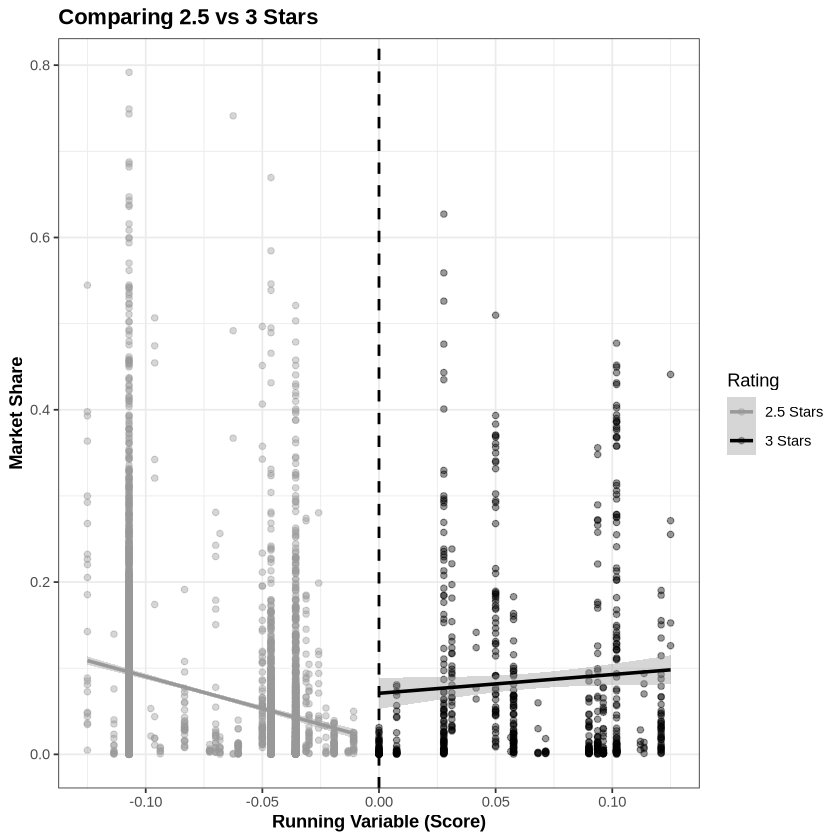

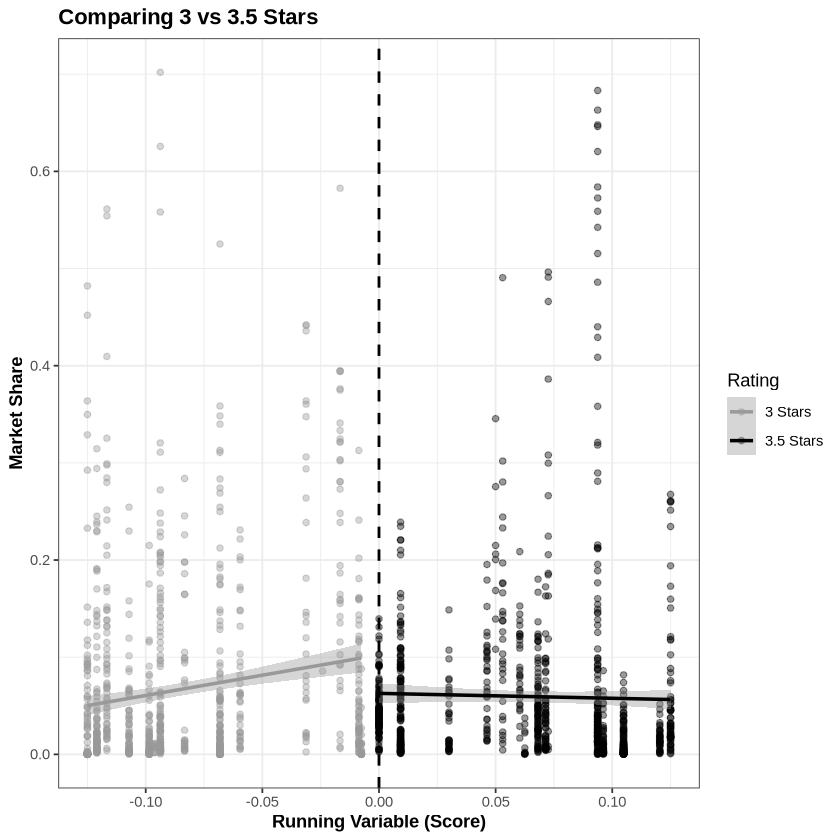

In [97]:
ma_25star_candidates <- data.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(2.5, 3)
  )

n_candidates_total <- nrow(ma_25star_candidates)
n_candidates_by_score <- ma_25star_candidates %>% count(partc_score)

ma_25star <- ma_25star_candidates %>%
  filter(
    raw_rating >= 2.5,
    raw_rating <= 3,
    (raw_rating >= 2.75 & Star_Rating == 3) | (raw_rating < 2.75 & Star_Rating == 2.5)
  )

ma.rd1 <- ma_25star %>%
  mutate(market_share = avg_enrollment / avg_enrolled,
         score = raw_rating - 2.75,
         treat = (score>=0),
         window = (score>=-.125 & score<=.125),
         score_treat=score*treat)

p1 <- ggplot(ma.rd1 %>% filter(window == TRUE),
             aes(x = score, y = market_share, color = treat)) +
  geom_point(alpha = 0.4, size = 1.5) +
  geom_smooth(method = "lm", se = TRUE) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "black", linewidth = 0.8) +
  scale_color_manual(values = c("FALSE" = "grey60", "TRUE" = "black"),
                     labels = c("2.5 Stars", "3 Stars")) +
  labs(title = "Comparing 2.5 vs 3 Stars", x = "Running Variable (Score)",
       y = "Market Share", color = "Rating") +
  theme_bw() +
  theme(
    plot.title  = element_text(face = "bold"),
    axis.title  = element_text(face = "bold")
  )

ma_25star_candidates <- data.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(3, 3.5)
  )

n_candidates_total <- nrow(ma_25star_candidates)
n_candidates_by_score <- ma_25star_candidates %>% count(partc_score)

ma_25star <- ma_25star_candidates %>%
  filter(
    raw_rating >= 3,
    raw_rating <= 3.5,
    (raw_rating >= 3.25 & Star_Rating == 3.5) | (raw_rating < 3.25 & Star_Rating == 3)
  )

ma.rd2 <- ma_25star %>%
  mutate(market_share = avg_enrollment / avg_enrolled,
         score = raw_rating - 3.25,
         treat = (score>=0),
         window = (score>=-.125 & score<=.125),
         score_treat=score*treat)

p2 <- ggplot(ma.rd2 %>% filter(window == TRUE),
             aes(x = score, y = market_share, color = treat)) +
  geom_point(alpha = 0.4, size = 1.5) +
  geom_smooth(method = "lm", se = TRUE) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "black", linewidth = 0.8) +
  scale_color_manual(values = c("FALSE" = "grey60", "TRUE" = "black"),
                     labels = c("3 Stars", "3.5 Stars")) +
  labs(title = "Comparing 3 vs 3.5 Stars", x = "Running Variable (Score)",
       y = "Market Share", color = "Rating") +
  theme_bw() +
  theme(
    plot.title  = element_text(face = "bold"),
    axis.title  = element_text(face = "bold")
  )

p1
p2

We do see an abrupt increment in market share concording to values below and above the threshold, particularly prominent near the threshold of comparison for 2.5 stars against 3 stars (i.e., the first plot), particularly, the drop from -0.10 to -0.05 in the upper plot. In contrast to this, we see a marginal increase in the number of plans from -0.10 to -0.05 in the lower plot. All in terms of the accumulated frequency of the dotted columns, showing market share in means of the number of plans.

## Problem 9

In [99]:
options(knitr.kable.NA = 0)
library(knitr)
library(kableExtra)

data.2010 %>%
  filter(!is.na(avg_enrollment)) %>%
  mutate(
    score = raw_rating - 2.75,
    group = ifelse(score >= 0, "Above Cutoff", "Below Cutoff")
  ) %>%
  filter(score >= -0.125, score <= 0.125) %>%
  mutate(
    HMO  = str_detect(plan_type, "HMO"),
    PartD = partd == "Yes"
  ) %>%
  group_by(group) %>%
  summarise(
    share_HMO   = round(mean(HMO),   3),
    share_PartD = round(mean(PartD), 3)
  ) %>%
  kable(
    col.names   = c("Group", "Share HMO", "Share Part D"),
    digits      = c(0, 3, 3),
    format.args = list(big.mark = ","),
    booktabs    = TRUE,
    caption     = "Plan Characteristics Near The 2.75 Star Rating Margin"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>Plan Characteristics Near the 2.75 Star Rating Margin</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Group </th>
   <th style="text-align:right;font-weight: bold;"> Share HMO </th>
   <th style="text-align:right;font-weight: bold;"> Share Part D </th>
   <th style="text-align:right;font-weight: bold;"> N </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Above Cutoff </td>
   <td style="text-align:right;"> 0.375 </td>
   <td style="text-align:right;"> 0.809 </td>
   <td style="text-align:right;"> 858 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Below Cutoff </td>
   <td style="text-align:right;"> 0.029 </td>
   <td style="text-align:right;"> 0.558 </td>
   <td style="text-align:right;"> 5,094 </td>
  </tr>
</tbody>
</table>

In [100]:
options(knitr.kable.NA = 0)
library(knitr)
library(kableExtra)

data.2010 %>%
  filter(!is.na(avg_enrollment)) %>%
  mutate(
    score = raw_rating - 3.25,
    group = ifelse(score >= 0, "Above Cutoff", "Below Cutoff")
  ) %>%
  filter(score >= -0.125, score <= 0.125) %>%
  mutate(
    HMO   = str_detect(plan_type, "HMO"),
    PartD = partd == "Yes"
  ) %>%
  group_by(group) %>%
  summarise(
    share_HMO   = round(mean(HMO),   3),
    share_PartD = round(mean(PartD), 3)
  ) %>%
  kable(
    col.names   = c("Group", "Share HMO", "Share Part D"),
    digits      = c(0, 3, 3),
    format.args = list(big.mark = ","),
    booktabs    = TRUE,
    caption     = "Plan Characteristics Near The 3.25 Star Rating Margin"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>Plan Characteristics Near the 3.25 Star Rating Margin</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Group </th>
   <th style="text-align:right;font-weight: bold;"> Share HMO </th>
   <th style="text-align:right;font-weight: bold;"> Share Part D </th>
   <th style="text-align:right;font-weight: bold;"> N </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Above Cutoff </td>
   <td style="text-align:right;"> 0.380 </td>
   <td style="text-align:right;"> 0.848 </td>
   <td style="text-align:right;"> 1,003 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Below Cutoff </td>
   <td style="text-align:right;"> 0.609 </td>
   <td style="text-align:right;"> 0.845 </td>
   <td style="text-align:right;"> 1,164 </td>
  </tr>
</tbody>
</table>

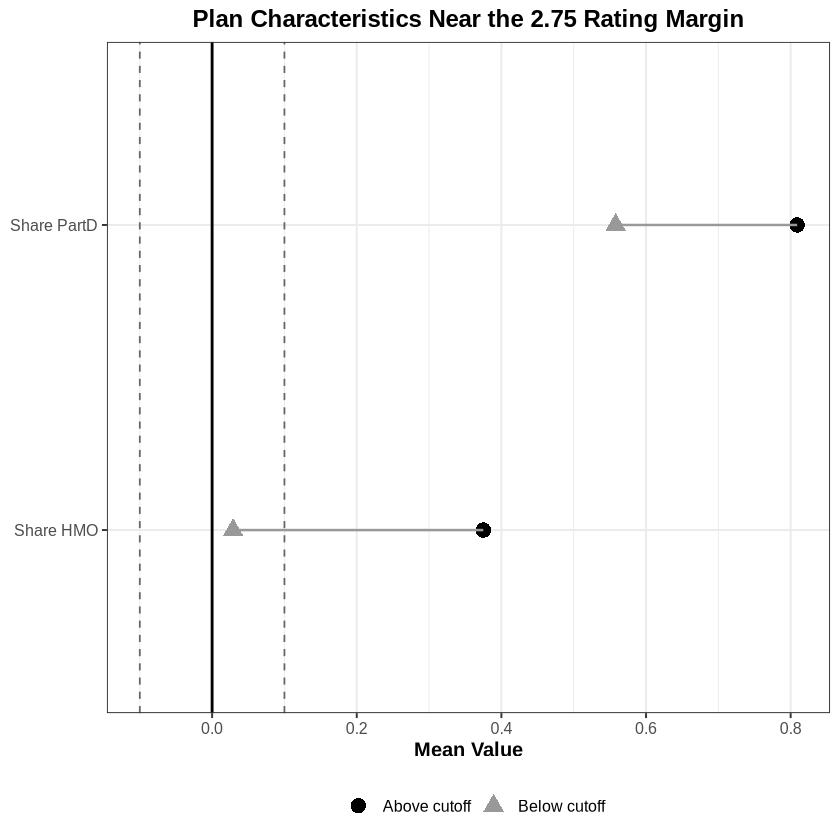

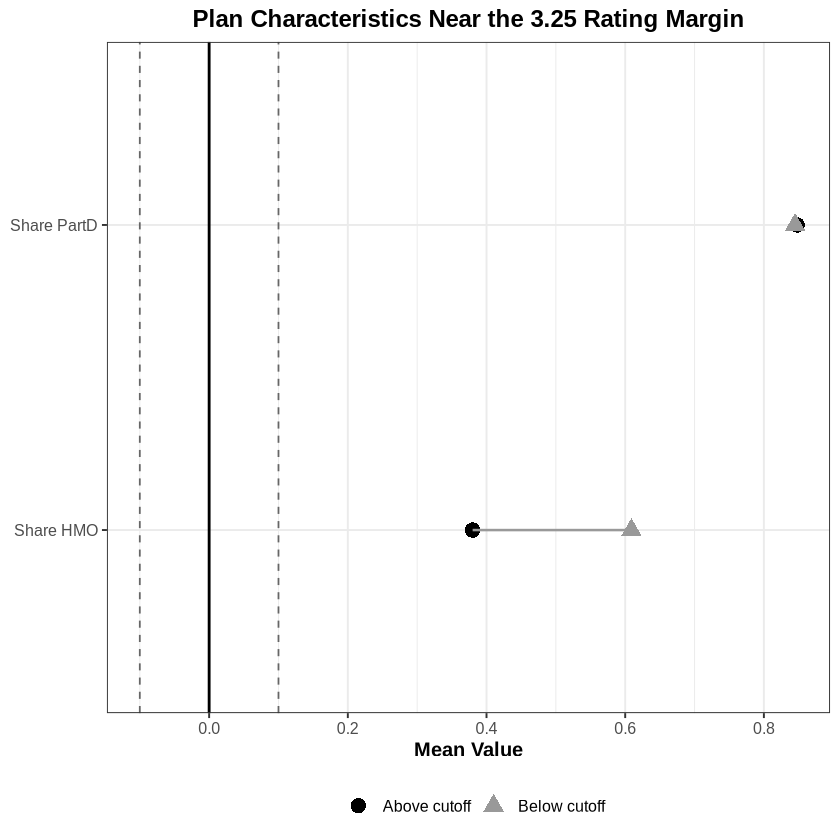

In [98]:
love_threshold_275 <- tibble(
  variable = rep(c("Share HMO", "Share PartD"), each = 2),
  group = rep(c("Above cutoff", "Below cutoff"), 2),
  value = c(0.375, 0.0291, 0.809, 0.558)
)

love_threshold_325 <- tibble(
  variable = rep(c("Share HMO", "Share PartD"), each = 2),
  group = rep(c("Above cutoff", "Below cutoff"), 2),
  value = c(0.380, 0.609, 0.848, 0.845)
)

love_plot <- function(data, title) {
  ggplot(data, aes(x = value, y = variable, color = group, shape = group)) +
    geom_point(size = 4) +
    geom_line(aes(group = variable), color = "grey60", linewidth = 0.7) +
    geom_vline(xintercept = 0, linewidth = 0.8) +
    geom_vline(xintercept = c(-0.1, 0.1), linetype = "dashed", color = "grey40") +
    scale_color_manual(values = c("Above cutoff" = "black", "Below cutoff" = "grey60")) +
    scale_shape_manual(values = c("Above cutoff" = 16, "Below cutoff" = 17)) +
    labs(
      title = title,
      x     = "Mean Value",
      y     = NULL,
      color = NULL,
      shape = NULL
    ) +
    theme_bw(base_size = 12) +
    theme(
      legend.position = "bottom",
      plot.title      = element_text(hjust = 0.5, face = "bold"),
      axis.title      = element_text(face = "bold")
    )
}

p1 <- love_plot(love_threshold_275, "Plan Characteristics Near the 2.75 Rating Margin")
p2 <- love_plot(love_threshold_325, "Plan Characteristics Near the 3.25 Rating Margin")
p1
p2

With a bandwidth of 0.125, we note that there is a substantially higher proportion of HMO-approved and Part D plans above the threshold for the nearest half-star comparison between 2.5 and 3-star ratings. Whereas, we see more HMO-approved plans below the threshold while comparing the nearest half-star for 3 against 3.5-star rated plans. But we see almost an equivalent proportion of Part D plans above and below the threshold. The proportions don't directly add to one row or column-wise since we're considering dummy fractions out of all possible plan categories that could be above or below the threshold.

## Problem 10

The effect of increased star rating is directly proportional to a larger number of plans, particularly prominent from the upward and downward slopes, above and below the threshold, respectively, in the Problem 8 plot comparing 2.5-star plans against 3-star ones. The effect is marginal beyond 3 stars increase upto the half-star between 3 vs 3.5-star plans. This makes sense as plans try to achieve a better rating for more enrollments. However, these results are highly sensitive to the chosen bandwidth, as evident from Problems 6 & 7. Further, an effect is added from the fact that the 3-star ratings experience the largest number of round-ups as compared to plans above it, thereby making that region particularly volatile to analysis.

The increased plan count with the effect of having a higher rating also becomes prominent as we see increased Part D contained plans for above the threshold of 2.5 vs 3 star comparison, with a marginal incremental effect going from 3 vs 3.5 star. Similarly, we see more HMO-aligned plans above the threshold of 2.5 vs 3 but under the threshold of 3 vs 3.5, showing accumulation and tending effect of more plan count with HMO benefits as ratings increase, since HMO indicates lower out-of-pocket costs and premiums.